##### Run in the dedicated `kea` environment created from `kea-env.yml`

#### Setup

In [1]:
import os
from kea3_pipeline import run_kea_pipeline
from kea3_consensus import consensus_table, cross_cluster_frequency, cluster_similarity
from kea3_permutation import run_label_shuffle_null, plot_null

ROOT = "./20260819-1231-s140206771-funny_keller"
PATH = os.path.join(ROOT, "True-data-Leiden-clusters.csv")
OUTDIR = os.path.join(ROOT, "kinase-enrichment")
HGNC_PATH = "hgnc_complete_set.txt"

N_PERM = 300
MINSIZE = 20
MAXSIZE = 999

# path to real output data for comparison to null
OBSERVED_MEANRANK = os.path.join(ROOT, "kinase-enrichment", "Combined_meanRank.csv")

#### Run KEA3 on the observed clusters

In [2]:
true_results = run_kea_pipeline(
    PATH,
    OUTDIR,
    clustering_column="LeidenCluster",
    minsize=MINSIZE,
    maxsize=MAXSIZE,
    hgnc_complete_set_path=HGNC_PATH,
    make_plots=True,
)

[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['SMAP']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['HLA']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']


#### Consensus analysis

In [3]:
true_consensus = consensus_table(true_results["meanRank"])
true_frequency = cross_cluster_frequency(true_consensus, min_n_top=4)
true_similarity = cluster_similarity(true_consensus, n=20, min_n_top=4)

true_consensus.to_csv(os.path.join(OUTDIR, "Consensus_rank.csv"), index=False)
true_frequency.to_csv(os.path.join(OUTDIR, "Cross_cluster_frequency.csv"), index=False)
true_similarity.to_csv(os.path.join(OUTDIR, "Cluster_similarity.csv"))

true_consensus

,Query Name,symbol_norm,n_libraries,n_top,median_pct,min_pct,n_substrate,n_top_substrate,n_interaction,n_top_interaction,frac_top,low_coverage,evidence,meanrank_rank,consensus_rank
0,Cluster_1,CSNK2A1,12,11,0.034431,0.002110,4,4,8,7,0.916667,False,both,1,1
1,Cluster_1,MAPK7,11,8,0.038348,0.004167,4,3,7,5,0.727273,False,both,4,2
2,Cluster_1,CDK1,11,7,0.018617,0.004219,3,2,8,5,0.636364,False,both,7,3
3,Cluster_1,PRKCA,12,7,0.071884,0.015564,4,3,8,4,0.583333,False,both,3,4
4,Cluster_1,MAPK1,12,7,0.088297,0.029167,4,2,8,5,0.583333,False,both,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15595,Cluster_31,ALPK3,3,0,0.974684,0.926782,0,0,3,0,0.000000,False,none,514,516
15596,Cluster_31,ALPK2,2,0,0.979694,0.974952,0,0,2,0,0.000000,True,none,519,517
15597,Cluster_31,ALPK1,4,0,0.982162,0.653061,1,0,3,0,0.000000,False,none,505,518
15598,Cluster_31,RSKR,1,0,0.986513,0.986513,0,0,1,0,0.000000,True,none,520,519


#### Label-shuffle null

In [4]:
null_df, observed, pvals = run_label_shuffle_null(
    clustered_phosphosites_path=PATH,
    observed_meanrank_path=OBSERVED_MEANRANK,
    hgnc_complete_set_path=HGNC_PATH,
    n_permutations=N_PERM,
    minsize=MINSIZE,
    maxsize=MAXSIZE,
    label_col="LeidenCluster",
    gene_col="Gene",
    workdir=os.path.join(ROOT, "kea-comparison", "perm_null"),
    top_n=12,
    min_n_top=4,
    seed=0,
)

Observed: 30 clusters eligible and analyzed
  n_clusters               30
  n_called_kinases         231
  mean_jaccard             0.1320514091928075
  frac_unique_kinases      0.33766233766233766
  background_fraction      0.2833333333333333
  mean_call_strength       6.647222222222222
  evidence_concordance     0.1709505373594397
  self_membership_delta    48.5
  n_clusters_eligible      30
  n_clusters_analyzed      30
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['SMAP']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
  permutation 1/300: clusters=30/30 analyzed/eligible, concordance=0.150, jaccard=0.200, unique=0.335
[normalize_query_genes] 1 symbols absent from HGNC, kept as-is: ['H1']
[normalize_query_genes] 1 symbols absent fr

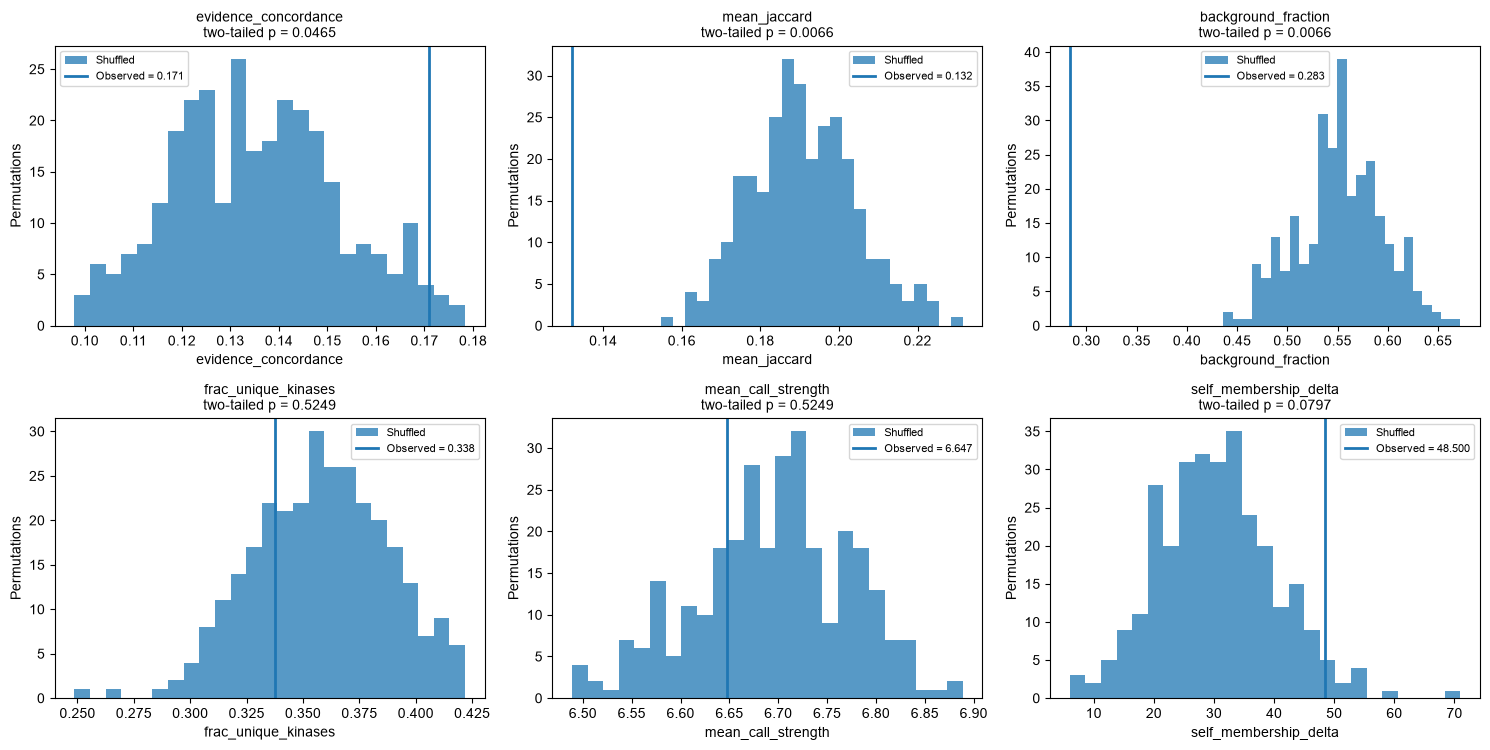

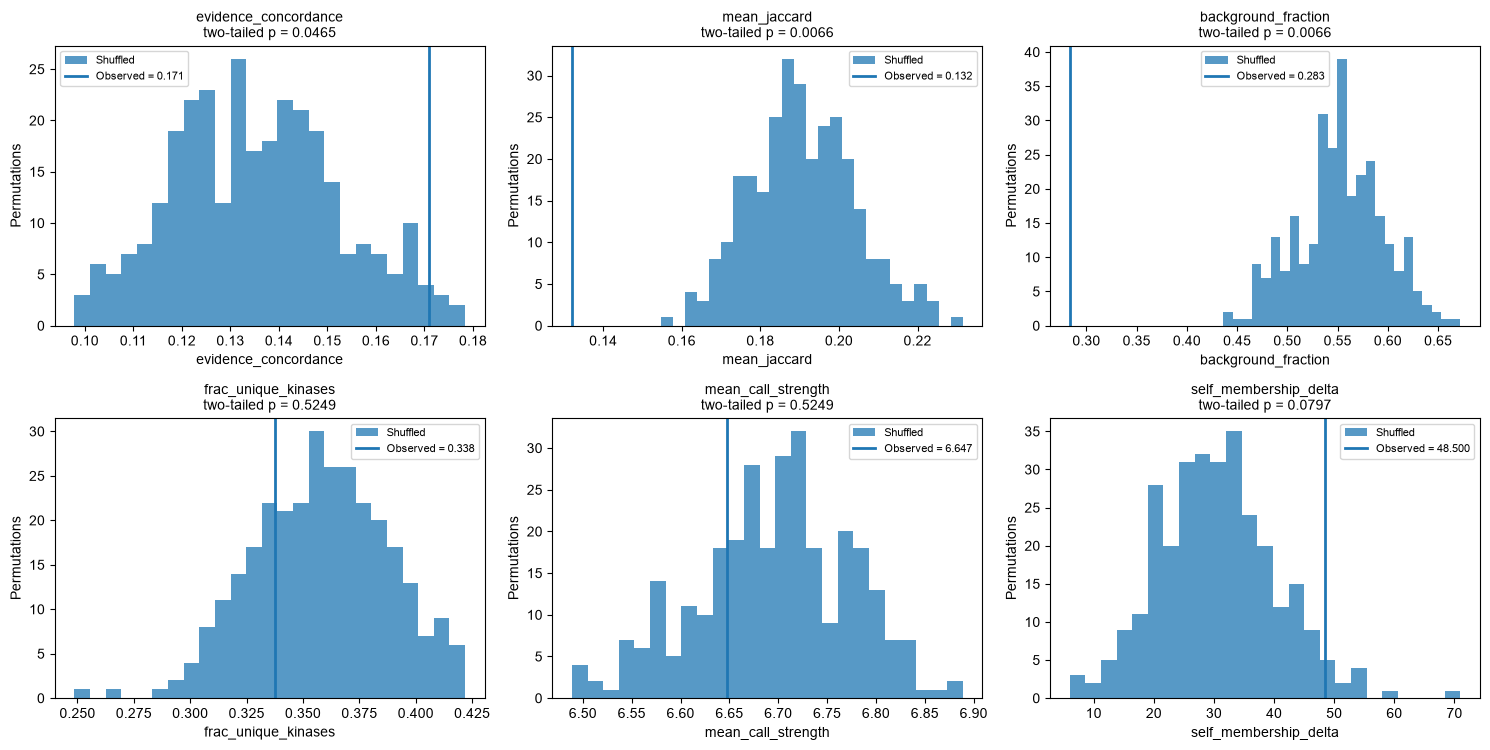

In [5]:
plot_null(
    null_df,
    observed,
    pvals,
    savepath=os.path.join(ROOT, "kea-comparison", "perm_null.png"),
)

| Statistic               | Question it asks                                           |  H1   |  
| ----------------------- | ---------------------------------------------------------- | ----: |
| `evidence_concordance`  | Do independent evidence types agree on cluster assignment? | Higher for real clusters |
| `mean_jaccard`          | Do clusters call different kinases from each other?        | Lower for real clusters |
| `background_fraction`   | How much do the leading calls rely on ubiquitous kinases?  | Lower for real clusters |
| `frac_unique_kinases`   | How many calls are restricted to one cluster?              | No change |
| `mean_call_strength`    | How much library agreement do the leading calls attract?   | No change |
| `self_membership_delta` | Are kinases called in the cluster containing them?         | No change |

## Interpreting them together

The first three ask whether clusters are distinct from each other. The fourth asks whether calls are confident, which shuffling should not damage. The fifth and sixth ask whether calls are correct, in the sense of matching independent evidence or matching cluster membership.

> evidence_concordance

Substrate libraries (motif models, curated substrate sets) and interaction libraries (PPI) are built by unrelated methods. For each kinase-cluster pair the script computes two agreement rates, `n_top_substrate/n_substrate` and `n_top_interaction/n_interaction`, then subtracts each value's kinase mean and its cluster mean and adds the grand mean. Double-centring removes the contribution of a kinase being well annotated everywhere and of a cluster enriching many kinases. The Pearson correlation of what remains answers whether the two classes agree about which cluster a kinase belongs to. Restricted to pairs with at least 3 substrate and 6 interaction libraries.

Hub bias cannot produce a positive value, because a hub kinase ranks high in every cluster and is therefore removed by the kinase-mean subtraction. `This is why it is the statistic to lead with.`

> mean_jaccard

Mean pairwise Jaccard overlap of the top-12 call sets across all cluster pairs. If the clustering separates real signalling contexts, different clusters should call different kinases. Sensitive to query size, since larger gene sets enrich a broader and more similar set of kinases.

> background_fraction

Within each `realization`, kinases called in at least half its clusters are defined as background. The statistic is the mean per-cluster fraction of top-12 calls drawn from that set. Because background is defined per `realization`, no curated promiscuous list is needed and the shuffled data is judged against its own background rather than yours.

> frac_unique_kinases

Of all kinases called anywhere, the fraction called in exactly one cluster. A partition that captures distinct biology should produce a long tail of cluster-restricted calls rather than the same kinases everywhere.

> mean_call_strength

Mean n_top across all top-12 calls; measures how many libraries agree on the leading calls rather than how specific they are. 

> self_membership_delta

Many enriched kinases are themselves phosphoproteins in the dataset. For each such kinase, the statistic compares its consensus rank in the cluster that contains it against the median rank across the other clusters, then takes the median difference over all such kinase-cluster pairs. Positive means kinases rank better in their own cluster.

This tests whether MoDPA groups a kinase with proteins it acts on, which is a direct claim about biological coherence. The caveat is that PPI libraries record kinase self-interaction and autophosphorylation, so part of the effect can arise mechanically once a kinase is in the query set. Treat it as supporting rather than primary evidence.

--------